In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import QuantLib as ql
import re

In [45]:
asof_dt = datetime(2026, 7, 17)
asof_ql_dt = to_ql_date(asof_dt)

In [31]:
usdjpy_fwd = (
    pd.read_csv("usdjpy_fwd.csv")
    .assign(delivery_date=lambda d: pd.to_datetime(d["delivery_date"]))
)
usdjpy_fwd

,label,delivery_date,outright
0,TOD,2026-07-17,162.450710
1,TOM,2026-07-21,162.402100
2,SPOT,2026-07-22,162.390000
3,SN,2026-07-23,162.377350
4,2W,2026-08-05,162.208500
5,3W,2026-08-12,162.119000
6,1M,2026-08-24,161.965150
7,2M,2026-09-24,161.559650
8,3M,2026-10-22,161.186500
9,4M,2026-11-24,160.754000


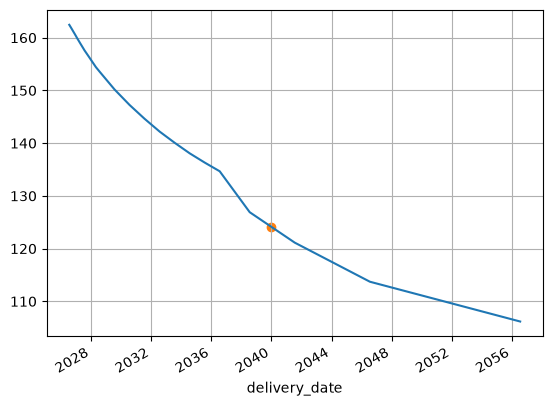

In [39]:
usd_calendar = ql.UnitedStates(ql.UnitedStates.Settlement)
jpy_calendar = ql.Japan()
calendar = ql.JointCalendar(
    usd_calendar,
    jpy_calendar,
    ql.JoinHolidays,
)

def to_py_date(date: ql.Date):
    return datetime(date.year(), date.month(), date.dayOfMonth())

def to_ql_date(date: datetime):
    return ql.Date(date.day, date.month, date.year)

def interp_fwd_rate(deal_date: datetime):
    delivery_date = to_py_date(calendar.advance(to_ql_date(deal_date), 2, ql.Days))
    target = pd.Timestamp(delivery_date).date()

    x = usdjpy_fwd["delivery_date"].apply(lambda x: x.toordinal()).to_numpy()
    y = usdjpy_fwd["outright"].apply(np.log).to_numpy()
    xt = float(delivery_date.toordinal())

    return float(np.exp(np.interp(xt, x, y)))

usdjpy_fwd.plot(x="delivery_date", y="outright", legend=None, grid=True)

dd = datetime(2040, 1, 1)
plt.scatter([dd], [interp_fwd_rate(dd)], c="C1")

plt.show()

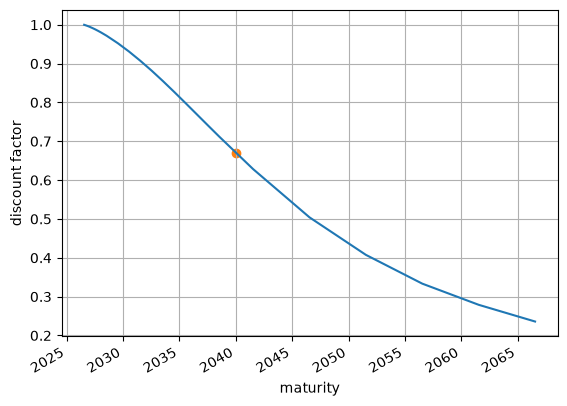

,tenor,ois,maturity,discount_factor
0,1D,0.97900,2026-07-21,0.999893
1,1W,0.97729,2026-07-24,0.999813
2,2W,0.97750,2026-07-31,0.999625
3,3W,0.97844,2026-08-07,0.999437
4,1M,0.97875,2026-08-17,0.999169
5,2M,0.97993,2026-09-17,0.998338
6,3M,0.99625,2026-10-19,0.997441
7,4M,1.02613,2026-11-17,0.996554
8,5M,1.04839,2026-12-17,0.995625
9,6M,1.07771,2027-01-19,0.994538


In [41]:
jpy_ois = (
    pd.read_csv("jpy_ois.csv")
    .assign(maturity=lambda d: pd.to_datetime(d["maturity"]))
)

def interp_df(deal_date: datetime):
    x = jpy_ois["maturity"].apply(lambda x: x.toordinal()).to_numpy()
    y = jpy_ois["discount_factor"].apply(np.log).to_numpy()
    return np.exp(np.interp(deal_date.toordinal(), x, y))

jpy_ois.plot(x="maturity", y="discount_factor", grid=True, legend=None, ylabel="discount factor")
plt.scatter([dd], [interp_df(dd)], c="C1")
plt.show()

jpy_ois

PRDCのクーポン$q_t$は（フロアとキャップを考えなければ）$c_f$と$c_d$、クーポン計算期間$\alpha_t$を用いて次のように決められる
$$q_t = \left(c_f {FX_t \over FX_0} - c_d\right)\alpha_t$$
PVを評価するには$FX_t$にフォワード$F_t$を代入し割り引く
$$\sum_t PV[q_t] = \sum_t\left(c_f {F_t \over FX_0} - c_d \right)\alpha_t DF_t$$
理論価格がパーに等しいとする
$$DF_T+\sum_t PV[q_t]=1$$
$c_f$と$c_d$の関係は、
$$DF_T+c_f\sum_t{F_t\over FX_0}-c_d\sum_t\alpha_t DF_t=1$$
$c_d$を$c_f$について解く
$$c_d=c_f{\sum_t{F_t\over FX_0}\alpha_t DF_t\over\sum_t\alpha_t DF_t}-{1-DF_T\over\sum_t\alpha_t DF_T}$$
市場不変のシナリオで年率期待利回り$r$を求める

$F_t=FX_0$として
$$
\begin{align}
r&=c_f-c_d\\
&=c_f-c_f+{1-DF_T\over\sum_t\alpha_t DF_t}\\
&={1-DF_T\over\sum_t\alpha_t DF_t}
\end{align}
$$

In [60]:
maturity = calendar.advance(asof_ql_dt, 5, ql.Years)

coupon_dates = []
coupon_date = asof_ql_dt
while coupon_date <= maturity:
    coupon_date = calendar.advance(coupon_date, 6, ql.Months)
    coupon_dates.append(to_py_dt(coupon_date))

day_count = ql.Actual365Fixed()
def year_frac(start: datetime, maturity: datetime):
    return day_count.yearFraction(to_ql_date(start), to_ql_date(maturity))

df_T = 1 - interp_df(to_py_dt(maturity))
df_coupon = sum(
    year_frac(coupon_dates[i - 1] if i > 0 else asof_dt, date)
    * interp_df(date)
    for i, date in enumerate(coupon_dates)
)

print(f"exp. annualized yield: {df_T / df_coupon * 100:.2f}%")

exp. annualized yield: 1.94%
